In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import pretty_midi as pm

import matplotlib.pyplot as plt
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append('..')
from utils import find_files

In [2]:
midiset = ['1_genre', '2_random', '3_maetest'][1]
audioset = 'dk'
transcription_models = ['oaf', 'kong', 'T5', 'toyama', 'edwards']

path_true = f'../data/{midiset}'
path_pred = f'../data/{audioset}/{midiset}_{audioset}'

dynamics_levels = [0, 1, 2]
velocities = {}

for dynamics in dynamics_levels:
    velocities[dynamics] = {}
        
    # true velocities
    sorted_paths_true = find_files(path_true, f'*_D{dynamics}.mid')
    velocities[dynamics]['true'] = []
    for piece_true in tqdm(sorted_paths_true, desc=f'Dynamics {dynamics} | Ground Truth MIDI'):
        pm_true = pm.PrettyMIDI(piece_true)
        for inst in pm_true.instruments:
            velocities[dynamics]['true'].extend([note.velocity for note in inst.notes])
    
    # predicted velocities for each model
    for model in transcription_models:
        sorted_paths_pred = find_files(path_pred, f'*_D{dynamics}_*{model}.mid')
        velocities[dynamics][model] = []
        for piece_pred in tqdm(sorted_paths_pred, desc=f'Dynamics {dynamics} | {model}\'s transcriptions'):
            pm_pred = pm.PrettyMIDI(piece_pred)
            for inst in pm_pred.instruments:
                velocities[dynamics][model].extend([note.velocity for note in inst.notes])

Dynamics 0 | Ground Truth MIDI: 100%|██████████| 24/24 [00:00<00:00, 50.86it/s]
Dynamics 0 | oaf's transcriptions: 100%|██████████| 24/24 [00:00<00:00, 78.98it/s] 
Dynamics 0 | kong's transcriptions: 100%|██████████| 24/24 [00:00<00:00, 49.01it/s]
Dynamics 0 | T5's transcriptions: 100%|██████████| 24/24 [00:00<00:00, 47.70it/s] 
Dynamics 0 | toyama's transcriptions: 100%|██████████| 24/24 [00:00<00:00, 67.13it/s] 
Dynamics 0 | edwards's transcriptions: 100%|██████████| 24/24 [00:00<00:00, 62.88it/s] 
Dynamics 1 | Ground Truth MIDI: 100%|██████████| 24/24 [00:00<00:00, 62.16it/s] 
Dynamics 1 | oaf's transcriptions: 100%|██████████| 24/24 [00:00<00:00, 82.45it/s] 
Dynamics 1 | kong's transcriptions: 100%|██████████| 24/24 [00:00<00:00, 63.41it/s] 
Dynamics 1 | T5's transcriptions: 100%|██████████| 24/24 [00:00<00:00, 50.89it/s] 
Dynamics 1 | toyama's transcriptions: 100%|██████████| 24/24 [00:00<00:00, 77.43it/s] 
Dynamics 1 | edwards's transcriptions: 100%|██████████| 24/24 [00:00<00:00

## Grid subplots

In [3]:
fs_title=16
fs_axis=14
fs_ticks=12

### Figure 13

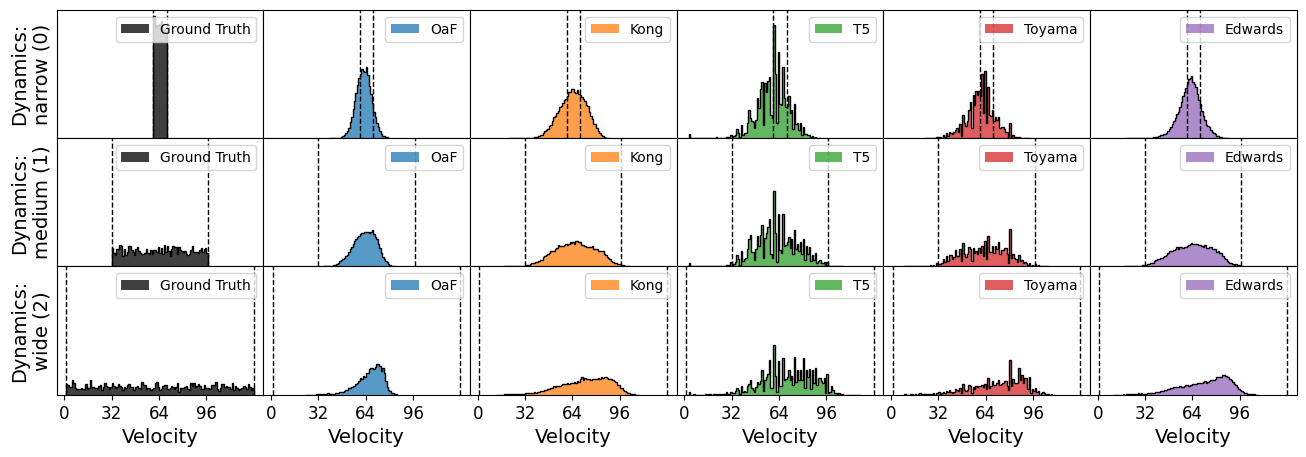

In [4]:
log = False; alpha = 0.75; sharey=True;
fig, axs = plt.subplots(3, 6, figsize=(16, 5), sharex=True, sharey=sharey, gridspec_kw={'wspace': 0.0, 'hspace': 0.0})

colors = {'true': 'black', 'oaf': 'tab:blue', 'kong': 'tab:orange', 'T5': 'tab:green', 'toyama': 'tab:red', 'edwards': 'tab:purple'}
dyn_range = {0: (60, 68), 1: (32, 96), 2: (1, 127)}
dyn2label = {0: 'narrow', 1: 'medium', 2: 'wide'}

mid2label = {'oaf': 'OaF', 'kong': 'Kong', 'T5': 'T5', 'toyama': 'Toyama', 'edwards': 'Edwards', 'true': 'Ground Truth'}

for row, dynamics in enumerate(dynamics_levels):
    for col, midiset in enumerate(velocities[dynamics].keys()):
        ax = axs[row, col]
        vel_values = velocities[dynamics][midiset]
        # bins = max(vel_values) - min(vel_values) + 1
        bins = range(min(vel_values), max(vel_values) + 2)
        ax.hist(vel_values, bins=bins, log=log,
                histtype='bar', color=colors[midiset], alpha=alpha, label=mid2label[midiset], density=False)
        ax.hist(vel_values, bins=bins, log=log,
                histtype='step', color='black', linewidth=1.0)
        
        # Fill area between two x-values (e.g., 40 and 60) with grey color
        # ax.axvspan(dyn_range[dynamics][0], dyn_range[dynamics][1], color='grey', alpha=0.5)
        # Draw vertical lines at the boundaries
        ax.axvline(dyn_range[dynamics][0], color='black', linestyle='--', linewidth=1.0)
        ax.axvline(dyn_range[dynamics][1]+1, color='black', linestyle='--', linewidth=1.0)

        ax.legend(loc='upper right')

        # if row == 0:
        #     ax.set_title(f'MIDI: {midiset}')
        if row == 2:
            ax.set_xlabel('Velocity', fontsize=fs_axis)
            ax.set_xticks(np.arange(0, 128, 32))
            ax.tick_params(axis='x', labelsize=fs_ticks)
        if col == 0:
            ax.set_ylabel(f'Dynamics:\n{dyn2label[dynamics]} ({dynamics})', fontsize=fs_axis)
        # remove y-axis ticks
        ax.set_yticks([])

# fig.savefig(f'../paper/figs/random_velocity_hist_small.pdf', bbox_inches='tight')
plt.show()

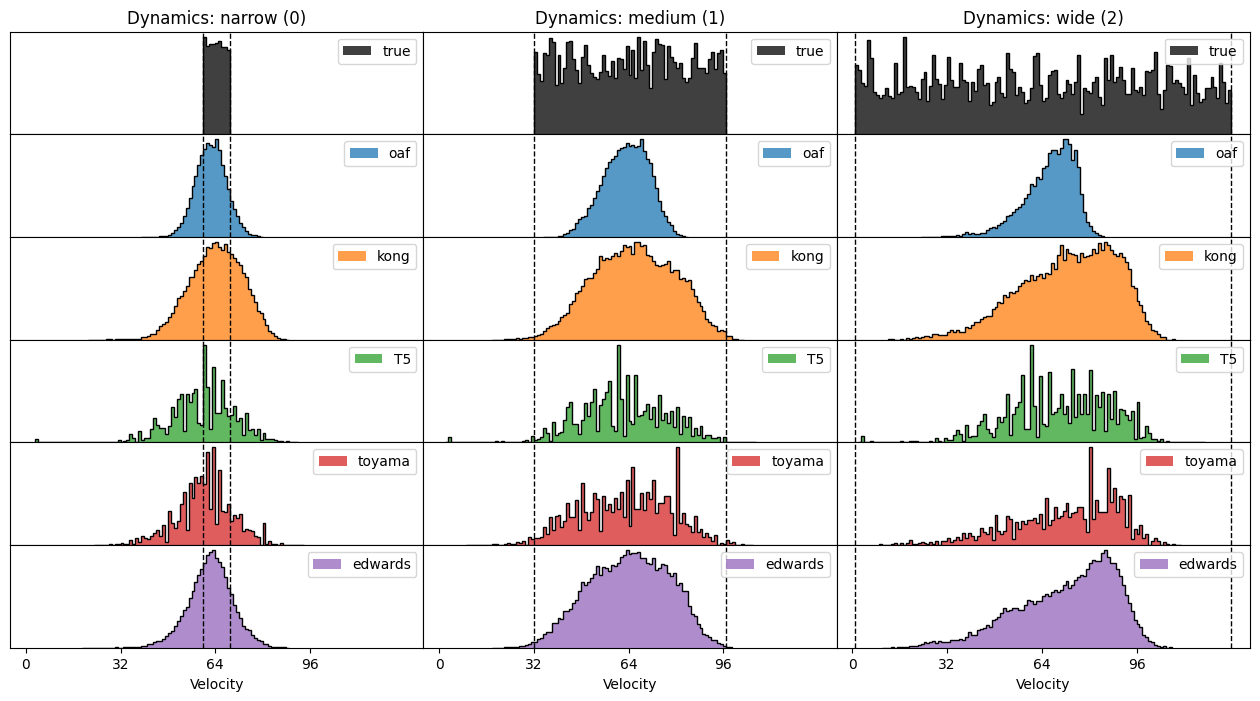

In [5]:
log = False; alpha = 0.75; sharey=False;
fig, axs = plt.subplots(6, 3, figsize=(16, 8), sharex=True, sharey=sharey, gridspec_kw={'wspace': 0.0, 'hspace': 0.0})

colors = {'true': 'black', 'oaf': 'tab:blue', 'kong': 'tab:orange', 'T5': 'tab:green', 'toyama': 'tab:red', 'edwards': 'tab:purple'}
dyn_range = {0: (60, 68), 1: (32, 96), 2: (1, 127)}
dyn2label = {0: 'narrow', 1: 'medium', 2: 'wide'}

for col, dynamics in enumerate(dynamics_levels):
    for row, midiset in enumerate(velocities[dynamics].keys()):
        ax = axs[row, col]
        vel_values = velocities[dynamics][midiset]
        # bins = max(vel_values) - min(vel_values) + 1
        bins = range(min(vel_values), max(vel_values) + 2)
        ax.hist(vel_values, bins=bins, log=log,
                histtype='bar', color=colors[midiset], alpha=alpha, label=midiset, density=False)
        ax.hist(vel_values, bins=bins, log=log,
                histtype='step', color='black', linewidth=1.0)
        
        # Fill area between two x-values (e.g., 40 and 60) with grey color
        # ax.axvspan(dyn_range[dynamics][0], dyn_range[dynamics][1], color='grey', alpha=0.5)
        # Draw vertical lines at the boundaries
        ax.axvline(dyn_range[dynamics][0], color='black', linestyle='--', linewidth=1.0)
        ax.axvline(dyn_range[dynamics][1]+1, color='black', linestyle='--', linewidth=1.0)

        ax.legend(loc='upper right')

        if row == 0:
            ax.set_title(f'Dynamics: {dyn2label[dynamics]} ({dynamics})')
        if row == 5:
            ax.set_xlabel('Velocity')
            ax.set_xticks(np.arange(0, 128, 32))
        # if col == 0:
        #     ax.set_ylabel(f'{midiset}')
        # remove y-axis ticks
        ax.set_yticks([])

# fig.savefig(f'../paper/figs/random_velocity_hist_large.pdf', bbox_inches='tight')
plt.show()

# END